In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureRavdess.csv')

In [ ]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [4]:
import joblib

# Load the saved scaler
scaler = joblib.load("../scaler.pkl")

# Load the saved model
gender_model = tf.keras.models.load_model("../gender_classification_model.h5")

W0000 00:00:1762260047.790705 2281050 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
X_gender = data.iloc[:, :193].values
X_scaled = scaler.transform(X_gender)
gender_predictions = gender_model.predict(X_scaled)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [6]:
print(gender_predictions)

[[7.7384239e-04]
 [7.8950549e-04]
 [1.0120951e-03]
 ...
 [9.9847502e-01]
 [9.9787855e-01]
 [9.9846315e-01]]


In [7]:
male_rows = gender_predictions.flatten() < 0.5  # 0 for Male, 1 for Female

df = data[male_rows]

print(f"Filtered dataset contains {df.shape[0]} male samples.")

Filtered dataset contains 719 male samples.


In [8]:
df.shape

(719, 196)

In [9]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375,-518.176025,54.336693,-16.867956,2.470917,-4.073838,-2.748888,-13.374091,-6.024971,-16.421869,-2.043707,...,31.550327,-0.011495,0.014177,-0.008497,-0.027965,-0.001463,0.007953,1,8,23
1376,-502.163391,49.330410,-16.674372,6.953362,-1.735307,-1.708595,-17.710266,-5.345790,-14.760635,-1.683560,...,31.989208,-0.043424,0.013255,-0.030656,0.050061,0.003688,0.007049,1,8,23
1377,-499.994263,50.926987,-19.440176,3.803090,-7.180909,-2.145453,-16.375141,-6.704348,-15.546900,-1.911119,...,32.237853,-0.059843,0.048440,-0.045319,0.020689,0.010588,0.016066,1,8,23
1378,-481.682251,41.021809,-19.435980,-0.163736,-10.369910,-2.922106,-15.791293,-7.187538,-15.690004,-3.325412,...,31.312768,-0.032609,0.030134,-0.100309,0.004273,-0.013313,-0.004990,1,8,23


In [10]:
data.iloc[:,-3] == 0

0       False
1       False
2       False
3       False
4       False
        ...  
1435     True
1436     True
1437     True
1438     True
1439     True
Name: 0.1, Length: 1440, dtype: bool

In [11]:
X_speaker = df.iloc[:, -1].copy()
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [12]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,14.502933,15.547618,17.645388,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,15.213718,15.513745,17.582760,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,14.972030,15.697508,17.437520,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,15.242136,15.597314,16.492804,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,14.636722,16.023571,17.020093,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375,-518.176025,54.336693,-16.867956,2.470917,-4.073838,-2.748888,-13.374091,-6.024971,-16.421869,-2.043707,...,15.563899,16.786573,17.289161,31.550327,-0.011495,0.014177,-0.008497,-0.027965,-0.001463,0.007953
1376,-502.163391,49.330410,-16.674372,6.953362,-1.735307,-1.708595,-17.710266,-5.345790,-14.760635,-1.683560,...,15.518351,17.003934,17.874535,31.989208,-0.043424,0.013255,-0.030656,0.050061,0.003688,0.007049
1377,-499.994263,50.926987,-19.440176,3.803090,-7.180909,-2.145453,-16.375141,-6.704348,-15.546900,-1.911119,...,15.092518,16.634495,17.128656,32.237853,-0.059843,0.048440,-0.045319,0.020689,0.010588,0.016066
1378,-481.682251,41.021809,-19.435980,-0.163736,-10.369910,-2.922106,-15.791293,-7.187538,-15.690004,-3.325412,...,15.157907,16.104991,16.717183,31.312768,-0.032609,0.030134,-0.100309,0.004273,-0.013313,-0.004990


In [13]:
y

0       1
1       1
2       1
3       1
4       2
       ..
1375    8
1376    8
1377    8
1378    8
1379    8
Name: 0.2, Length: 719, dtype: int64

In [14]:
X_speaker

0        1
1        1
2        1
3        1
4        1
        ..
1375    23
1376    23
1377    23
1378    23
1379    23
Name: speaker, Length: 719, dtype: int64

In [15]:
X.shape, y.shape

((719, 193), (719,))

In [16]:
from sklearn.utils import shuffle

X, y, X_speaker = shuffle(X, y, X_speaker, random_state=42)

In [17]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
240,-691.452515,82.156662,3.882375,20.036530,8.277701,2.692780,-3.566173,-1.029916,-4.295271,3.589765,...,15.651561,17.276828,16.533962,31.378136,-0.038085,0.044314,-0.048185,0.010280,0.010960,0.028039
284,-708.608093,66.181213,6.354491,25.112740,0.583152,3.341432,-3.133984,2.310285,-2.769953,6.368120,...,15.668430,15.694806,16.773541,31.399500,-0.035361,-0.015063,-0.005487,-0.036799,0.016123,0.006055
39,-590.983276,74.518639,-9.625761,22.812243,2.404797,4.461318,-9.366790,-8.053039,-16.515903,2.641336,...,15.891860,16.726666,18.814396,32.223629,-0.015185,0.011484,0.134152,0.024999,0.003172,0.023705
1091,-681.945312,78.568947,16.016911,33.139301,9.768853,17.960642,-7.706484,0.865045,-14.381108,4.019069,...,18.316176,17.988523,17.983600,34.090939,-0.006495,0.020611,-0.083216,0.052248,-0.003992,0.017558
379,-429.855042,58.556293,-17.621305,13.152417,3.173928,-6.004189,-23.124149,1.841852,-13.718226,3.929267,...,17.259158,18.998492,20.257584,33.922676,-0.060652,0.003370,-0.074988,0.026420,0.035579,0.014364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,-503.989868,68.907585,-9.939764,14.944476,-2.818100,6.875752,-26.140736,1.054880,-5.804341,-4.376976,...,16.759984,18.640375,19.054267,32.058884,0.026932,-0.021074,0.026702,-0.029949,0.021343,-0.001228
166,-573.106812,56.762455,-2.930424,20.731886,-2.298028,4.026749,-19.395811,1.150211,-10.176166,0.917685,...,14.974672,16.329427,16.116918,31.336124,-0.024688,-0.019084,-0.034166,-0.040140,0.013771,-0.000854
510,-563.606079,70.182686,-14.853501,19.245783,15.801292,1.466610,-5.570126,-3.481671,-16.712420,2.720659,...,16.961951,17.358991,18.009310,33.101683,-0.018980,0.012866,0.003344,-0.025613,0.006480,-0.005541
855,-573.245605,80.446121,-12.591578,18.710548,11.635873,1.314883,-6.154487,3.073936,-10.015546,1.910821,...,15.516219,16.650834,17.991156,31.533914,-0.018724,0.019571,-0.084000,-0.056433,0.011422,-0.012925


In [18]:
X_speaker

240      5
284      5
39       1
1091    19
379      7
        ..
131      3
166      3
510      9
855     15
162      3
Name: speaker, Length: 719, dtype: int64

In [19]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [20]:
y1

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], shape=(719, 8))

In [21]:
X.shape, y1.shape

((719, 193), (719, 8))

In [22]:
X2_speaker = X_speaker.copy().to_numpy()
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [23]:
X2.shape, X2_speaker.shape, y2.shape

((719, 193), (719,), (719,))

In [24]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    #model.add(Conv1D(128, 5,padding='same',))
    #model.add(Activation('relu'))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(8))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    #model.summary()
    return model

In [25]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [26]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-691.452515,82.156662,3.882375,20.036530,8.277701,2.692780,-3.566173,-1.029916,-4.295271,3.589765,...,15.651561,17.276828,16.533962,31.378136,-0.038085,0.044314,-0.048185,0.010280,0.010960,0.028039
1,-708.608093,66.181213,6.354491,25.112740,0.583152,3.341432,-3.133984,2.310285,-2.769953,6.368120,...,15.668430,15.694806,16.773541,31.399500,-0.035361,-0.015063,-0.005487,-0.036799,0.016123,0.006055
2,-590.983276,74.518639,-9.625761,22.812243,2.404797,4.461318,-9.366790,-8.053039,-16.515903,2.641336,...,15.891860,16.726666,18.814396,32.223629,-0.015185,0.011484,0.134152,0.024999,0.003172,0.023705
3,-681.945312,78.568947,16.016911,33.139301,9.768853,17.960642,-7.706484,0.865045,-14.381108,4.019069,...,18.316176,17.988523,17.983600,34.090939,-0.006495,0.020611,-0.083216,0.052248,-0.003992,0.017558
4,-429.855042,58.556293,-17.621305,13.152417,3.173928,-6.004189,-23.124149,1.841852,-13.718226,3.929267,...,17.259158,18.998492,20.257584,33.922676,-0.060652,0.003370,-0.074988,0.026420,0.035579,0.014364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714,-503.989868,68.907585,-9.939764,14.944476,-2.818100,6.875752,-26.140736,1.054880,-5.804341,-4.376976,...,16.759984,18.640375,19.054267,32.058884,0.026932,-0.021074,0.026702,-0.029949,0.021343,-0.001228
715,-573.106812,56.762455,-2.930424,20.731886,-2.298028,4.026749,-19.395811,1.150211,-10.176166,0.917685,...,14.974672,16.329427,16.116918,31.336124,-0.024688,-0.019084,-0.034166,-0.040140,0.013771,-0.000854
716,-563.606079,70.182686,-14.853501,19.245783,15.801292,1.466610,-5.570126,-3.481671,-16.712420,2.720659,...,16.961951,17.358991,18.009310,33.101683,-0.018980,0.012866,0.003344,-0.025613,0.006480,-0.005541
717,-573.245605,80.446121,-12.591578,18.710548,11.635873,1.314883,-6.154487,3.073936,-10.015546,1.910821,...,15.516219,16.650834,17.991156,31.533914,-0.018724,0.019571,-0.084000,-0.056433,0.011422,-0.012925


In [27]:
X3_speaker = pd.DataFrame(X2_speaker)
X3_speaker

,0
0,5
1,5
2,1
3,19
4,7
...,...
714,3
715,3
716,9
717,15


In [28]:
speakers = X_speaker.unique()
speakers

array([ 5,  1, 19,  7,  3, 17, 23, 11, 15, 21, 13,  9])

In [29]:
X3_col = X3_speaker.rename(columns={0: 'speaker'})
X3_col

,speaker
0,5
1,5
2,1
3,19
4,7
...,...
714,3
715,3
716,9
717,15


In [30]:
X_combined = pd.concat([X3, X3_col], axis=1)
X_combined

,0,1,2,3,4,5,6,7,8,9,...,184,185,186,187,188,189,190,191,192,speaker
0,-691.452515,82.156662,3.882375,20.036530,8.277701,2.692780,-3.566173,-1.029916,-4.295271,3.589765,...,17.276828,16.533962,31.378136,-0.038085,0.044314,-0.048185,0.010280,0.010960,0.028039,5
1,-708.608093,66.181213,6.354491,25.112740,0.583152,3.341432,-3.133984,2.310285,-2.769953,6.368120,...,15.694806,16.773541,31.399500,-0.035361,-0.015063,-0.005487,-0.036799,0.016123,0.006055,5
2,-590.983276,74.518639,-9.625761,22.812243,2.404797,4.461318,-9.366790,-8.053039,-16.515903,2.641336,...,16.726666,18.814396,32.223629,-0.015185,0.011484,0.134152,0.024999,0.003172,0.023705,1
3,-681.945312,78.568947,16.016911,33.139301,9.768853,17.960642,-7.706484,0.865045,-14.381108,4.019069,...,17.988523,17.983600,34.090939,-0.006495,0.020611,-0.083216,0.052248,-0.003992,0.017558,19
4,-429.855042,58.556293,-17.621305,13.152417,3.173928,-6.004189,-23.124149,1.841852,-13.718226,3.929267,...,18.998492,20.257584,33.922676,-0.060652,0.003370,-0.074988,0.026420,0.035579,0.014364,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714,-503.989868,68.907585,-9.939764,14.944476,-2.818100,6.875752,-26.140736,1.054880,-5.804341,-4.376976,...,18.640375,19.054267,32.058884,0.026932,-0.021074,0.026702,-0.029949,0.021343,-0.001228,3
715,-573.106812,56.762455,-2.930424,20.731886,-2.298028,4.026749,-19.395811,1.150211,-10.176166,0.917685,...,16.329427,16.116918,31.336124,-0.024688,-0.019084,-0.034166,-0.040140,0.013771,-0.000854,3
716,-563.606079,70.182686,-14.853501,19.245783,15.801292,1.466610,-5.570126,-3.481671,-16.712420,2.720659,...,17.358991,18.009310,33.101683,-0.018980,0.012866,0.003344,-0.025613,0.006480,-0.005541,9
717,-573.245605,80.446121,-12.591578,18.710548,11.635873,1.314883,-6.154487,3.073936,-10.015546,1.910821,...,16.650834,17.991156,31.533914,-0.018724,0.019571,-0.084000,-0.056433,0.011422,-0.012925,15


In [31]:
# Get random 5 speakers

speaker_counts = X_combined['speaker'].value_counts()
total_speakers = speaker_counts.head(12).index.to_numpy()
selected_speakers = np.random.choice(total_speakers, size=5, replace=False)

print("Selected speakers:", selected_speakers)

Selected speakers: [ 7  9 13 11  3]


In [32]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=715
num_fea=125
a=create_index(kfold,totalsize)

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='ravdess_speaker_male_193'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_scaled, axis=2)
    x_testcnn = np.expand_dims(X_test_scaled, axis=2)

    m1= model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {i} Test Accuracy: {score_eval[1]:.4f}")

    # Save data for reproducibility
    np.save(os.path.join(savedir, f"X_train_fold{i}.npy"), x_traincnn)
    np.save(os.path.join(savedir, f"y_train_fold{i}.npy"), y_train)

    np.save(os.path.join(savedir, f"X_test_fold{i}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{i}.npy"), y_test)

    # Save model
    model_name = f"Model_{i}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{i}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)


print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")


===== Fold 0 =====
Test speaker: 7
Train speakers: [ 1  3  5  9 11 13 15 17 19 21 23]
No overlap in fold 0.
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.2018 - loss: 2.0656 - val_accuracy: 0.1833 - val_loss: 2.0594
Epoch 2/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3399 - loss: 1.7872 - val_accuracy: 0.1833 - val_loss: 2.0731
Epoch 3/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3778 - loss: 1.6848 - val_accuracy: 0.1667 - val_loss: 2.0825
Epoch 4/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.4052 - loss: 1.6048 - val_accuracy: 0.1667 - val_loss: 2.0851
Epoch 5/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4643 - loss: 1.5110 - val_accuracy: 0.1833 - val_loss: 2.0935
Epoch 6/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5357 - loss: 1.4340 - val_accuracy: 0.1833 - val_loss: 2.0978
Epoch 7/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5402 - loss: 1.3897 - val_accuracy: 0.1833 - val_loss: 2.0994
Epoch 8/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5797 - loss: 1.3172 - val_accuracy: 0.1833 - val_l

Fold 0 Test Accuracy: 0.4667

===== Fold 1 =====
Test speaker: 9
Train speakers: [ 1  3  5  7 11 13 15 17 19 21 23]
No overlap in fold 1.


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.2200 - loss: 2.1150 - val_accuracy: 0.1833 - val_loss: 2.0661
Epoch 2/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3232 - loss: 1.7876 - val_accuracy: 0.1833 - val_loss: 2.0752
Epoch 3/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.3445 - loss: 1.7070 - val_accuracy: 0.1667 - val_loss: 2.0873
Epoch 4/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.4461 - loss: 1.5621 - val_accuracy: 0.1667 - val_loss: 2.0987
Epoch 5/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.4416 - loss: 1.5328 - val_accuracy: 0.1833 - val_loss: 2.1142
Epoch 6/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.4841 - loss: 1.4611 - val_accuracy: 0.1667 - val_loss: 2.1294
Epoch 7/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.5721 - loss: 1.3593 - val_accuracy: 0.1833 - val_loss: 2.1381
Epoch 8/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.5706 - loss: 1.3614 - val_accuracy: 0.

Fold 3 Test Accuracy: 0.5333

===== Fold 4 =====
Test speaker: 3
Train speakers: [ 1  5  7  9 11 13 15 17 19 21 23]
No overlap in fold 4.


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.2018 - loss: 2.0553 - val_accuracy: 0.2167 - val_loss: 2.0391
Epoch 2/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.2974 - loss: 1.7962 - val_accuracy: 0.2833 - val_loss: 2.0559
Epoch 3/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.3687 - loss: 1.6858 - val_accuracy: 0.1500 - val_loss: 2.0647
Epoch 4/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.4158 - loss: 1.6050 - val_accuracy: 0.1500 - val_loss: 2.0678
Epoch 5/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.4886 - loss: 1.5216 - val_accuracy: 0.1500 - val_loss: 2.0758
Epoch 6/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.4841 - loss: 1.5000 - val_accuracy: 0.1500 - val_loss: 2.0738
Epoch 7/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5250 - loss: 1.4105 - val_accuracy: 0.2167 - val_loss: 2.0799
Epoch 8/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5675 - loss: 1.3559 - val_accuracy: 0.

Fold 4 Test Accuracy: 0.4500

===== Cross-validation results =====
Fold 0: Loss=1.6296, Accuracy=0.4667
Fold 1: Loss=1.6680, Accuracy=0.4833
Fold 2: Loss=1.8176, Accuracy=0.4000
Fold 3: Loss=1.6797, Accuracy=0.5333
Fold 4: Loss=1.7200, Accuracy=0.4500

Average accuracy: 0.4667


In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix, classification_report

savedir = 'ravdess_speaker_male_193'
num_folds = 5
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

fold_reports = []
fold_macro_f1 = []

for i in range(num_folds):
    model_name = f"Model_{i}"
    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")
    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    report_dict = classification_report(y_true_labels, y_pred_labels,
                                        target_names=listik, digits=4, output_dict=True)
    fold_reports.append(report_dict)
    fold_macro_f1.append(report_dict['macro avg']['f1-score'])

    print(f"\n{'='*60}")
    print(f"Fold {i}: Accuracy = {acc:.2f}%")
    print(f"{'='*60}")
    print(classification_report(y_true_labels, y_pred_labels,
                                target_names=listik, digits=4))

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)

mean_acc = np.mean(accuracies)
print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))
n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")


# Macro-F1 summary
macro_f1_arr = np.array(fold_macro_f1)
mean_macro_f1 = np.mean(macro_f1_arr)
std_macro_f1 = np.std(macro_f1_arr)
ci95_f1 = 1.96 * (std_macro_f1 / np.sqrt(num_folds))
print(f"\nMacro-F1: {mean_macro_f1:.4f} ± {std_macro_f1:.4f}  "
      f"\n95% CI: [{mean_macro_f1 - ci95_f1:.4f}, {mean_macro_f1 + ci95_f1:.4f}]")

# Per-class precision / recall / F1 (mean ± SD across folds)
print(f"\n{' Per-Class Metrics (mean ± SD across folds)':=^93}\n")
print(f"{'Class':<12} {'Precision':>20} {'Recall':>20} {'F1-Score':>20} {'Support':>17}")
print("-" * 93)
for cls in listik:
    p = np.array([r[cls]['precision'] for r in fold_reports])
    r = np.array([r[cls]['recall'] for r in fold_reports])
    f = np.array([r[cls]['f1-score'] for r in fold_reports])
    s = np.array([r[cls]['support'] for r in fold_reports])
    print(f"{cls:<12}        "
          f"{np.mean(p):>6.4f} ± {np.std(p):<6.4f}       "
          f"{np.mean(r):>6.4f} ± {np.std(r):<6.4f}       "
          f"{np.mean(f):>6.4f} ± {np.std(f):<6.4f}     "
          f"{np.mean(s):>8.1f}")
print("-" * 93)

2026-03-02 12:49:43.141012: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 12:49:43.141246: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 12:49:43.169731: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 12:49:43.818528: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or


Fold 0: Accuracy = 46.67%
              precision    recall  f1-score   support

       angry     0.2000    0.5000    0.2857         4
        calm     0.5000    0.5000    0.5000         8
     disgust     0.4000    0.2500    0.3077         8
     fearful     0.3636    0.5000    0.4211         8
       happy     0.5714    0.5000    0.5333         8
     neutral     0.6250    0.6250    0.6250         8
         sad     0.6667    0.5000    0.5714         8
   surprised     0.6000    0.3750    0.4615         8

    accuracy                         0.4667        60
   macro avg     0.4908    0.4688    0.4632        60
weighted avg     0.5102    0.4667    0.4751        60


Fold 1: Accuracy = 48.33%
              precision    recall  f1-score   support

       angry     0.1875    0.7500    0.3000         4
        calm     0.6000    0.7500    0.6667         8
     disgust     0.7500    0.3750    0.5000         8
     fearful     0.3636    0.5000    0.4211         8
       happy     0.8333 

/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

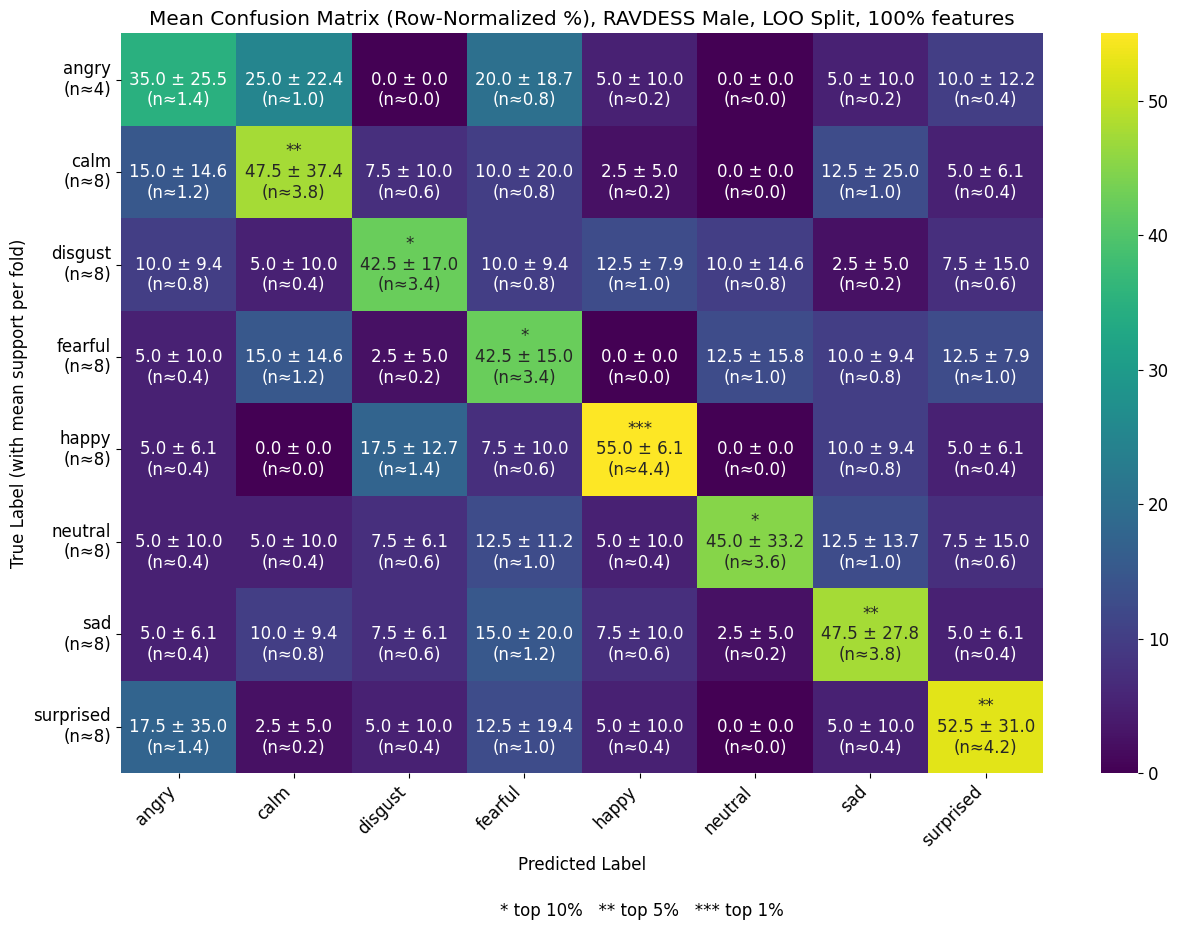

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 12})

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

np.save('cm_ravdess_speaker_male_193.npy', conf_matrices_percent)

mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Mean raw counts per fold
mean_counts = np.mean(conf_matrices, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols + raw counts
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}\n(n≈{mean_counts[i, j]:.1f})"

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

# Per-class support (mean samples per true class per fold)
mean_support = np.mean(conf_matrices.sum(axis=2), axis=0)
row_labels = [f"{name}\n(n≈{sup:.0f})" for name, sup in zip(listik, mean_support)]

# Plot
plt.figure(figsize=(13, 9))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)
ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(row_labels, rotation=0)
plt.title("Mean Confusion Matrix (Row-Normalized %), RAVDESS Male, LOO Split, 100% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label (with mean support per fold)")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%\n",
            ha="center", fontsize=12)
plt.show()